In [2]:
from itertools import chain

import anndata as ad
import itertools
import networkx as nx
import pandas as pd
import scanpy as sc
import scglue
import seaborn as sns
from matplotlib import rcParams

In [3]:
scglue.plot.set_publication_params()
rcParams["figure.figsize"] = (4, 4)

In [4]:
rna = ad.read_h5ad("../process/framework/obj//rna_E12.5_1_scglue_prepare.h5ad")
atac = ad.read_h5ad("../process/framework/obj//atac_E12.5_1_scglue_prepare.h5ad")
guidance = nx.read_graphml("/dev/shm/guidance.graphml.gz")

FileNotFoundError: [Errno 2] No such file or directory: '/dev/shm/guidance.graphml.gz'

In [5]:
guidance = nx.read_graphml("../process/scglue//guidance.graphml.gz")

In [6]:
split = atac.var_names.str.split(r"[:-]")
atac.var["chrom"] = split.map(lambda x: x[0])
atac.var["chromStart"] = split.map(lambda x: x[1]).astype(int)
atac.var["chromEnd"] = split.map(lambda x: x[2]).astype(int)
atac.var.head()

,name,chrom,chromStart,chromEnd
chr1-3046200-3047106,chr1-3046200-3047106,chr1,3046200,3047106
chr1-3094219-3095343,chr1-3094219-3095343,chr1,3094219,3095343
chr1-3165484-3166526,chr1-3165484-3166526,chr1,3165484,3166526
chr1-3184626-3185668,chr1-3184626-3185668,chr1,3184626,3185668
chr1-3185936-3186838,chr1-3185936-3186838,chr1,3185936,3186838


In [8]:
scglue.data.get_gene_annotation(
    rna, gtf="../../../database/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz",
    gtf_by="gene_name"
)
rna.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
Xkr4,chr1,3205900.0,3671498.0
Gm1992,chr1,3466586.0,3513553.0
Rp1,chr1,3999556.0,4409241.0
Sox17,chr1,4490930.0,4497354.0
Mrpl15,chr1,4773205.0,4785739.0


In [10]:
varIndex = rna.var.loc[:, ["chrom", "chromStart", "chromEnd"]].dropna().index
rnawget ftp://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M25/gencode.vM25.chr_patch_hapl_scaff.annotation.gtf.gz = rna[:,varIndex]

In [11]:
guidance = scglue.genomics.rna_anchored_guidance_graph(rna, atac)
guidance

window_graph: 100%|██████████| 21638/21638 [00:05<00:00, 3825.95it/s]


In [13]:
scglue.models.configure_dataset(
    rna, "NB", use_highly_variable=True,
    use_layer="counts", use_rep="X_pca"
)

/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/site-packages/scglue/models/__init__.py:124: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[config.ANNDATA_KEY] = data_config


In [14]:
scglue.models.configure_dataset(
    atac, "NB", use_highly_variable=True,
    use_rep="X_lsi"
)

In [15]:
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    atac.var.query("highly_variable").index
)).copy()

In [16]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "atac": atac}, guidance_hvf,
    fit_kws={"directory": "glue"}
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using GPU 0 as computation device.


/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 43588
[INFO] SCGLUEModel: Setting `max_epochs` = 203
[INFO] SCGLUEModel: Setting `patience` = 17
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 9
[INFO] SCGLUETrainer: Using training directory: "glue/pretrain"


/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.481, 'g_kl': 0.004, 'g_elbo': 0.485, 'x_rna_nll': 0.671, 'x_rna_kl': 0.016, 'x_rna_elbo': 0.686, 'x_atac_nll': 0.132, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.133, 'dsc_loss': 0.682, 'vae_loss': 0.839, 'gen_loss': 0.804}, val={'g_nll': 0.479, 'g_kl': 0.004, 'g_elbo': 0.483, 'x_rna_nll': 0.673, 'x_rna_kl': 0.015, 'x_rna_elbo': 0.688, 'x_atac_nll': 0.131, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.132, 'dsc_loss': 0.688, 'vae_loss': 0.839, 'gen_loss': 0.805}, 6.4s elapsed
[INFO] SCGLUETrainer: [Epoch 20] train={'g_nll': 0.453, 'g_kl': 0.005, 'g_elbo': 0.457, 'x_rna_nll': 0.654, 'x_rna_kl': 0.016, 'x_rna_elbo': 0.67, 'x_atac_nll': 0.13, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.131, 'dsc_loss': 0.687, 'vae_loss': 0.819, 'gen_loss': 0.784}, val={'g_nll': 0.452, 'g_kl': 0.005, 'g_elbo': 0.457, 'x_rna_nll': 0.653, 'x_rna_kl': 0.016, 'x_rna_elbo': 0.669, 'x_atac_nll': 0.131, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.132, 'dsc_loss': 0.691, 'vae_loss': 0.819, 'ge

...

[INFO] estimate_balancing_weight: Matching clusters...
[INFO] estimate_balancing_weight: Matching array shape = (18, 20)...
[INFO] estimate_balancing_weight: Estimating balancing weight...
[INFO] fit_SCGLUE: Fine-tuning SCGLUE model...


/home/zhangyufeng/miniconda3/envs/scarches/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 43588
[INFO] SCGLUEModel: Setting `align_burnin` = 34
[INFO] SCGLUEModel: Setting `max_epochs` = 203
[INFO] SCGLUEModel: Setting `patience` = 17
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 9
[INFO] SCGLUETrainer: Using training directory: "glue/fine-tune"
[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.435, 'g_kl': 0.004, 'g_elbo': 0.44, 'x_rna_nll': 0.647, 'x_rna_kl': 0.016, 'x_rna_elbo': 0.663, 'x_atac_nll': 0.13, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.13, 'dsc_loss': 0.691, 'vae_loss': 0.811, 'gen_loss': 0.776}, val={'g_nll': 0.435, 'g_kl': 0.004, 'g_elbo': 0.44, 'x_rna_nll': 0.65, 'x_rna_kl': 0.016, 'x_rna_elbo': 0.666, 'x_atac_nll': 0.128, 'x_atac_kl': 0.001, 'x_atac_elbo': 0.128, 'dsc_loss': 0.677, 'vae_loss': 0.811, 'gen_loss': 0.778}, 8.

2024-07-31 11:38:28,216 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "97"...
[INFO] EarlyStopping: Restoring checkpoint "97"...


In [17]:
glue.save("../process/scglue/E12_scATAC_rna_glue.dill")
# glue = scglue.models.load_model("glue.dill")

In [18]:
rna.obsm["X_glue"] = glue.encode_data("rna", rna)
atac.obsm["X_glue"] = glue.encode_data("atac", atac)

In [19]:
combined = ad.concat([rna, atac])

In [20]:
sc.pp.neighbors(combined, use_rep="X_glue", metric="cosine")
sc.tl.umap(combined)

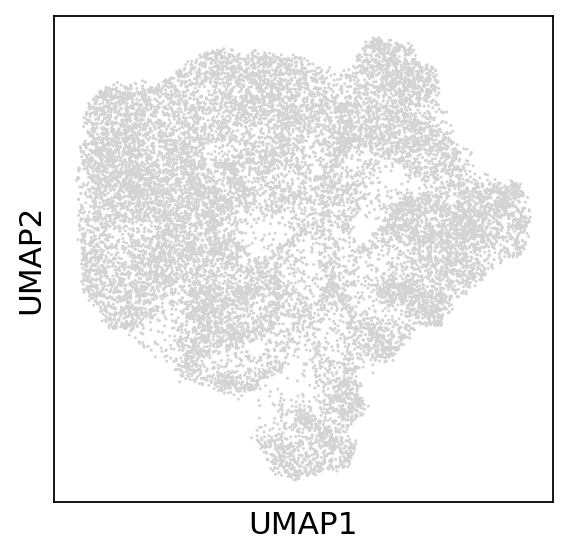

In [21]:
sc.pl.umap(combined)

In [24]:
combined.obs["group"]

E125_1_AAACCCAAGTCATGAA-1    E125
E125_1_AAACCCACAAGACCGA-1    E125
E125_1_AAACCCACATGCACTA-1    E125
E125_1_AAACCCAGTCAGTCGC-1    E125
E125_1_AAACCCAGTCCACGCA-1    E125
                             ... 
C2_TTTGTGTGTAGCGAGT-1         NaN
C2_TTTGTGTGTCCTATTT-1         NaN
C2_TTTGTGTTCCATCTAT-1         NaN
C2_TTTGTGTTCCGTGCAG-1         NaN
C2_TTTGTGTTCGTTGTAG-1         NaN
Name: group, Length: 16889, dtype: category
Categories (1, object): ['E125']

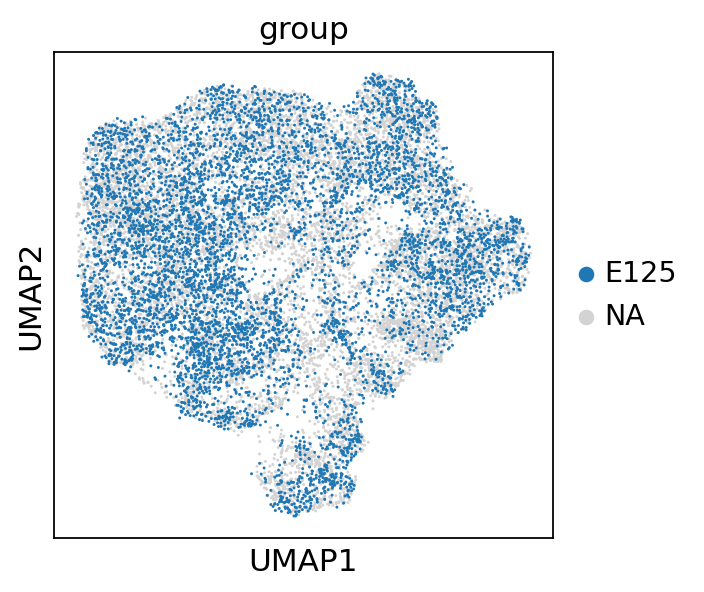

In [25]:
sc.pl.umap(combined,color="group")